--- 7-EVENT MARKET REPORT: Mar 27 PM ---
NCAA_Sweet16_S1      | $537.00  |        +135.5%
NCAA_Elite8_S2       | $221.00  |          +2.8%
Astros_Opening       | $58.00   |         -20.5%
Astros_Game_2        | $36.00   |         -20.0%
Rockets_Knicks       | $31.00   |          +6.9%
Peso_Pluma           | $160.00  |         +23.1%
Houston_Open         | $80.00   |         +77.8%


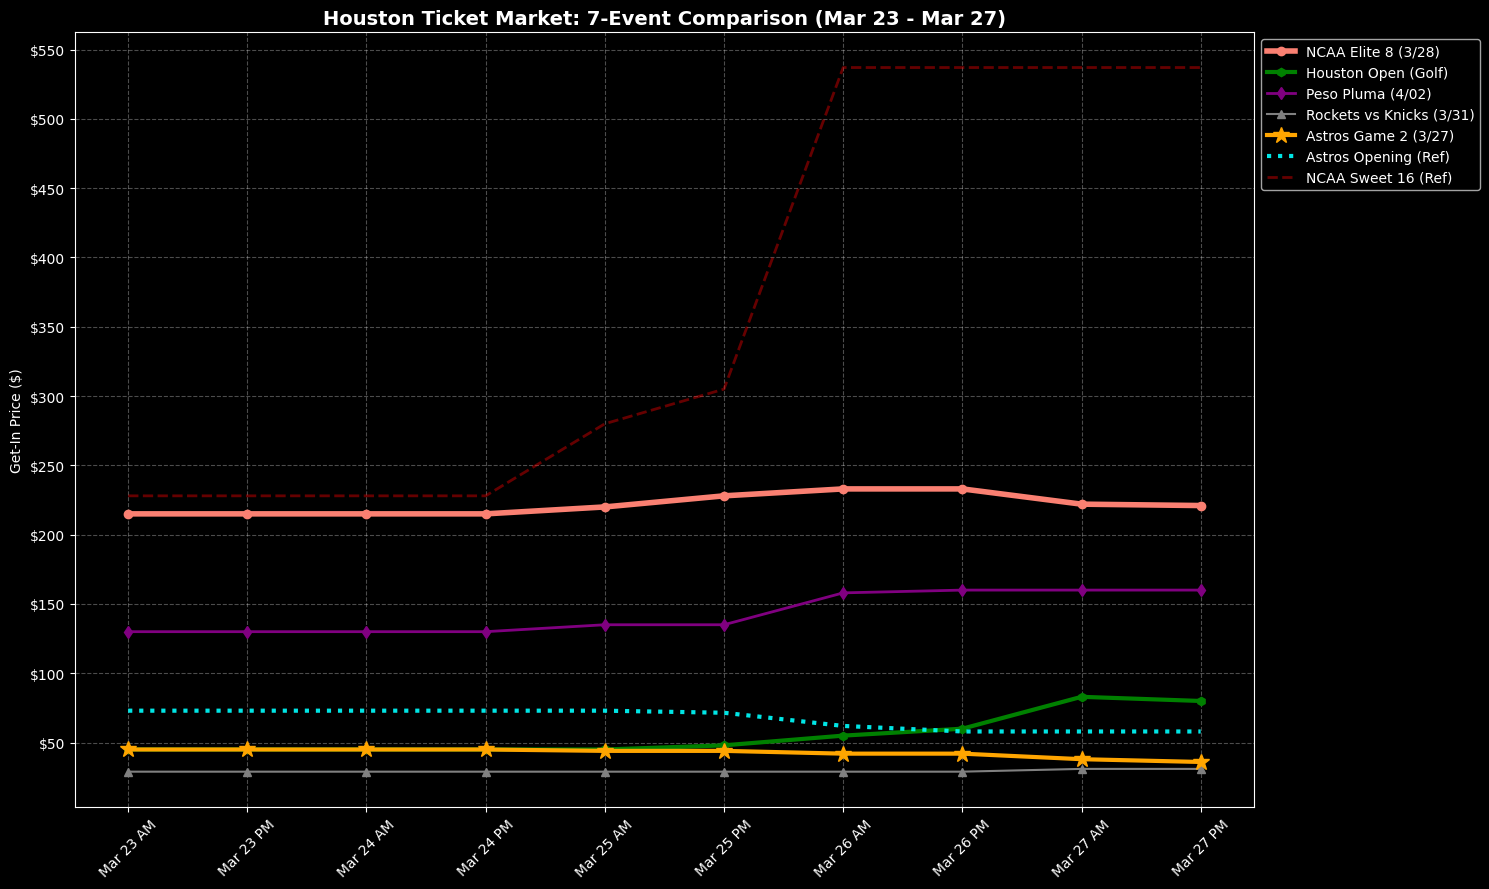

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # Required for the $50 steps

# 1. THE DATA (Synchronized 10-point tracking)
data = {
    'Time': [
        'Mar 23 AM', 'Mar 23 PM', 'Mar 24 AM', 'Mar 24 PM',
        'Mar 25 AM', 'Mar 25 PM', 'Mar 26 AM', 'Mar 26 PM',
        'Mar 27 AM', 'Mar 27 PM'
    ],
    'NCAA_Sweet16_S1': [228, 228, 228, 228, 280, 305, 537, 537, 537, 537],
    'NCAA_Elite8_S2':  [215, 215, 215, 215, 220, 228, 233, 233, 222, 221],
    'Astros_Opening':  [73, 73, 73, 73, 73, 71.5, 62, 58, 58, 58],
    'Astros_Game_2':   [45, 45, 45, 45, 44, 44, 42, 42, 38, 36],   # TONIGHT'S FLOOR
    'Rockets_Knicks':  [29, 29, 29, 29, 29, 29, 29, 29, 31, 31],
    'Peso_Pluma':      [130, 130, 130, 130, 135, 135, 158, 160, 160, 160],
    'Houston_Open':    [45, 45, 45, 45, 45, 48, 55, 60, 83, 80]
}

df = pd.DataFrame(data)

# 2. THE INSIGHT ENGINE
print(f"--- 7-EVENT MARKET REPORT: {df['Time'].iloc[-1]} ---")
for column in df.columns[1:]:
    original = df[column].iloc[0]
    current = df[column].iloc[-1]
    growth = ((current - original) / original) * 100
    print(f"{column:20} | ${current:<7.2f} | {growth:>+13.1f}%")

# 3. THE CHART
plt.figure(figsize=(15, 9))
ax = plt.gca() # Get the current axis to apply the $50 locator

# Active Events (Solid Lines)
plt.plot(df['Time'], df['NCAA_Elite8_S2'], marker='o', linewidth=4, label='NCAA Elite 8 (3/28)', color='salmon')
plt.plot(df['Time'], df['Houston_Open'], marker='h', linewidth=3, label='Houston Open (Golf)', color='green')
plt.plot(df['Time'], df['Peso_Pluma'], marker='d', linewidth=2, label='Peso Pluma (4/02)', color='purple')
plt.plot(df['Time'], df['Rockets_Knicks'], marker='^', label='Rockets vs Knicks (3/31)', color='gray')
plt.plot(df['Time'], df['Astros_Game_2'], marker='*', markersize=12, linewidth=3, label='Astros Game 2 (3/27)', color='orange')

# Historical Reference Lines (High Contrast)
plt.plot(df['Time'], df['Astros_Opening'], linestyle=':', linewidth=3, alpha=0.9, label='Astros Opening (Ref)', color='cyan')
plt.plot(df['Time'], df['NCAA_Sweet16_S1'], linestyle='--', linewidth=2, alpha=0.4, label='NCAA Sweet 16 (Ref)', color='red')

# --- ENFORCED $50 INCREMENTS ---
# This forces the axis to tick at every $50 exactly
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))

# Extra: Add Dollar signs to the Y-axis labels
formatter = ticker.FormatStrFormatter('$%d')
ax.yaxis.set_major_formatter(formatter)

plt.title("Houston Ticket Market: 7-Event Comparison (Mar 23 - Mar 27)", fontsize=14, fontweight='bold')
plt.ylabel("Get-In Price ($)")
plt.xticks(rotation=45)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, which='both', linestyle='--', alpha=0.3) # Grid will now follow the $50 ticks
plt.tight_layout()

plt.show()